**Variance Reduction Techniques**

In [471]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import qmc
import pandas as pd

**Parameters**

In [483]:
S0 = 100        
K = 100         
T = 1.0         
r = 0.05        
sigma = 0.2     
N = 100000

**Comparison of the different methods and their impact on the algorithm execution time**

Price of the European call option: 10.450583572185565
Method                 Mean Price      Std Dev   Time per Run (s)
Basic                   10.438990     0.048169           0.002449
Antithetic              10.453995     0.030406           0.001704
Control Variate         10.455464     0.016670           0.003248
Moment Matching         10.452008     0.006091           0.002690
Stratified              10.450604     0.000108           0.003218
Importance Sampling     10.451323     0.028454           0.003130
Sobol                   10.450594     0.000127           0.002108

Method                 Variance Reduction (%)      Time Change (%)
Basic                                    0.00                 0.00
Antithetic                              60.15               -30.40
Control Variate                         88.02                32.64
Moment Matching                         98.40                 9.85
Stratified                             100.00                31.42
Importance Samp

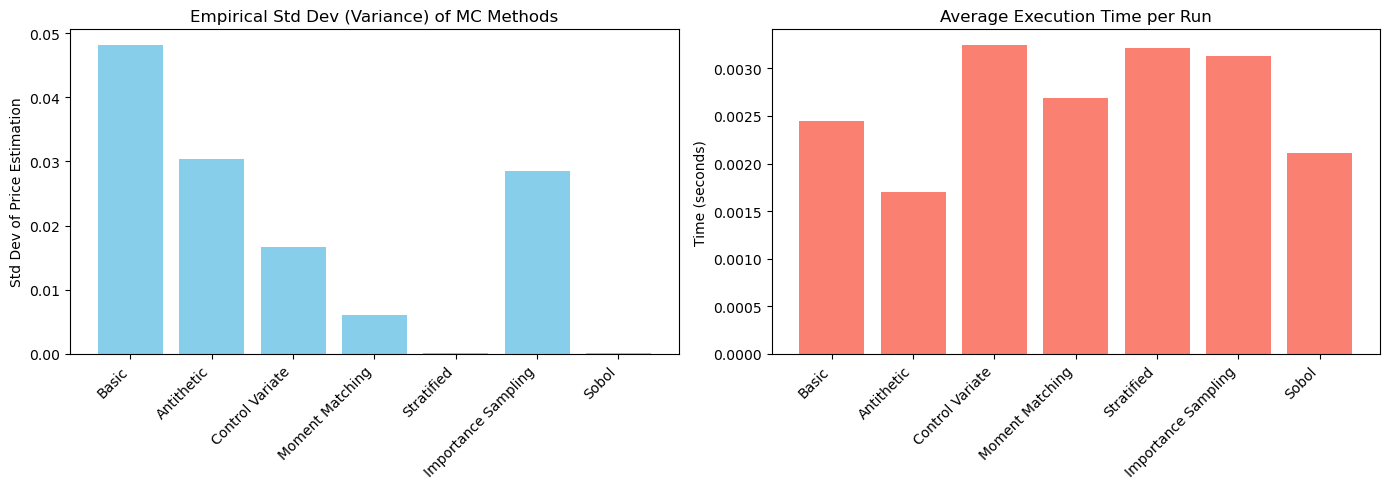

In [488]:
import numpy as np
from scipy.stats import norm, qmc
import time
import matplotlib.pyplot as plt

def bs_call_price(S0, K, T, r, sigma):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return price

true_price = bs_call_price(S0, K, T, r, sigma)
print(f"Price of the European call option: {true_price}")

def monte_carlo_call_basic(S0, K, T, r, sigma, N):
    Z = np.random.normal(0, 1, N)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(ST - K, 0)
    price = np.exp(-r * T) * np.mean(payoff)
    return price

def monte_carlo_call_antithetic(S0, K, T, r, sigma, N):
    half = N // 2
    Z = np.random.normal(0, 1, half)
    Z = np.concatenate([Z, -Z])
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(ST - K, 0)
    price = np.exp(-r * T) * np.mean(payoff)
    return price

def monte_carlo_call_control_variate(S0, K, T, r, sigma, N):
    Z = np.random.normal(0, 1, N)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(ST - K, 0)
    control = ST
    cov = np.cov(payoff, control)[0, 1]
    var_control = np.var(control)
    beta_opt = cov / var_control
    control_mean = S0 * np.exp(r * T)
    payoff_cv = payoff - beta_opt * (control - control_mean)
    price = np.exp(-r * T) * np.mean(payoff_cv)
    return price

def monte_carlo_call_moment_matching(S0, K, T, r, sigma, N):
    Z = np.random.normal(0, 1, N)
    Z = (Z - np.mean(Z)) / np.std(Z)  
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(ST - K, 0)
    price = np.exp(-r * T) * np.mean(payoff)
    return price

def monte_carlo_call_stratified(S0, K, T, r, sigma, N):
    U = (np.arange(N) + np.random.uniform(0, 1, N)) / N
    Z = norm.ppf(U)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(ST - K, 0)
    price = np.exp(-r * T) * np.mean(payoff)
    return price

def monte_carlo_call_importance_sampling(S0, K, T, r, sigma, N, mu_shift=0.3):
    Z = np.random.normal(mu_shift, 1, N)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(ST - K, 0)
    likelihood_ratio = np.exp(-mu_shift * Z + 0.5 * mu_shift**2)
    weighted_payoff = payoff * likelihood_ratio
    price = np.exp(-r * T) * np.mean(weighted_payoff)
    return price

def monte_carlo_call_sobol(S0, K, T, r, sigma, N):
    m = int(np.log2(N))
    N_sobol = 2**m  # puissance de 2 <= N
    sampler = qmc.Sobol(d=1, scramble=True)
    U = sampler.random(N_sobol).flatten()
    Z = norm.ppf(U)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(ST - K, 0)
    price = np.exp(-r * T) * np.mean(payoff)
    return price


runs = 50

methods = {
    "Basic": monte_carlo_call_basic,
    "Antithetic": monte_carlo_call_antithetic,
    "Control Variate": monte_carlo_call_control_variate,
    "Moment Matching": monte_carlo_call_moment_matching,
    "Stratified": monte_carlo_call_stratified,
    "Importance Sampling": monte_carlo_call_importance_sampling,
    "Sobol": monte_carlo_call_sobol
}

results = {}

for name, func in methods.items():
    prices = []
    start = time.perf_counter()
    for _ in range(runs):
        price = func(S0, K, T, r, sigma, N)
        prices.append(price)
    duration = time.perf_counter() - start
    
    prices = np.array(prices)
    mean_price = np.mean(prices)
    std_price = np.std(prices)
    time_per_run = duration / runs
    
    results[name] = {
        "mean_price": mean_price,
        "std_dev": std_price,
        "time_per_run": time_per_run
    }


print(f"{'Method':<20} {'Mean Price':>12} {'Std Dev':>12} {'Time per Run (s)':>18}")
print("="*64)
for name, res in results.items():
    print(f"{name:<20} {res['mean_price']:12.6f} {res['std_dev']:12.6f} {res['time_per_run']:18.6f}")


names = list(results.keys())
stds = [results[n]["std_dev"] for n in names]
times = [results[n]["time_per_run"] for n in names]


base_var = results["Basic"]["std_dev"] ** 2
base_time = results["Basic"]["time_per_run"]


print(f"\n{'Method':<20} {'Variance Reduction (%)':>24} {'Time Change (%)':>20}")
print("="*66)
for name in names:
    var_i = results[name]["std_dev"] ** 2
    time_i = results[name]["time_per_run"]
    var_gain_pct = 100 * (base_var - var_i) / base_var  
    time_change_pct = 100 * (time_i - base_time) / base_time  
    print(f"{name:<20} {var_gain_pct:24.2f} {time_change_pct:20.2f}")


fig, axs = plt.subplots(1, 2, figsize=(14,5))

axs[0].bar(names, stds, color='skyblue')
axs[0].set_title("Empirical Std Dev (Variance) of MC Methods")
axs[0].set_ylabel("Std Dev of Price Estimation")
axs[0].set_xticks(range(len(names)))
axs[0].set_xticklabels(names, rotation=45, ha='right')

axs[1].bar(names, times, color='salmon')
axs[1].set_title("Average Execution Time per Run")
axs[1].set_ylabel("Time (seconds)")
axs[1].set_xticks(range(len(names)))
axs[1].set_xticklabels(names, rotation=45, ha='right')



plt.tight_layout()
plt.show()